# Invisibility Cloak: Independent Samples t-Test

This dataset provides the number of mischievous acts committed by two groups: those with and without an invisibility cloak. The goal is to test whether the cloak has a significant effect.

Saving Invisibility Cloak.csv to Invisibility Cloak (3).csv


## Dataset

Participant,Cloak,Mischief
1,0,3
2,0,1
3,0,5
4,0,4
5,0,6
6,0,4
7,0,6
8,0,2
9,0,0
10,0,5


...

##Assumption 2: Independent Variable (Groups)


**Answer:** Satisfied

**Explanation:** The independent variable (Cloak) consists of two categorical, independent groups(0 = Without Cloak, 1 = With Cloak).

**Assumption 3.** Each participant belongs to only one group.

### Assumption 4. Outliers

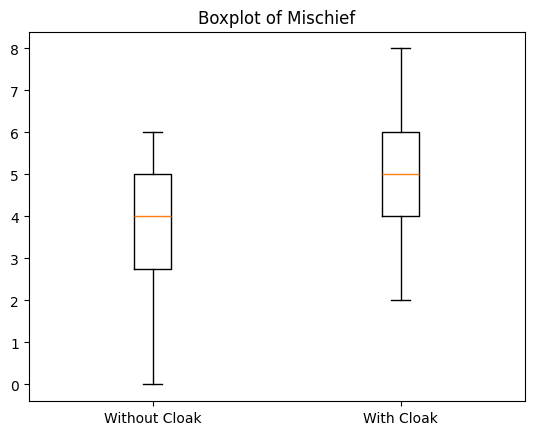

**Remark.** There are no significant outliers, as assessed by visual inspection of boxplots.

### Assumption 5. Normality

**Test of Normality (Shapiro-Wilk)**

Group,W,p
Without Cloak,0.913,0.231
With Cloak,0.973,0.936


**Remark.** The assumption of normality is not significant (p > 0.05). Hence, the dependent variable is normally distributed.

...

## Null Hypothesis

There is no significant difference between participants with and without an invisibility cloak in terms of their number of mischievous acts.

The results indicate that the difference is not statistically significant, t(22) = -1.713, p = 0.101. Therefore, we fail to reject the null hypothesis.

## APA Report

An independent samples t-test was conducted to compare mischief scores between participants with and without an invisibility cloak. Participants without the cloak (M = 3.75, SD = 1.91) and those with the cloak (M = 5.00, SD = 1.65) did not significantly differ, t(22) = -1.71, p = 0.101. These findings suggest that the invisibility cloak does not significantly affect mischief behavior.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

# Title
display(Markdown("# Invisibility Cloak: Independent Samples t-Test"))
display(Markdown(
"This dataset provides the number of mischievous acts committed by two groups: "
"those with and without an invisibility cloak. The goal is to test whether the cloak has a significant effect."
))

# Load Data
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Invisibility Cloak.csv')

display(Markdown("## Dataset"))
display(df.style.hide(axis="index"))

# Groups
group_no = df[df['Cloak'] == 0]['Mischief']
group_yes = df[df['Cloak'] == 1]['Mischief']

# Assumptions
display(Markdown("## Assumption Checks"))

# Assumption 1
display(Markdown(
"##Assumption 1: Dependent Variable (Scale)"
))
display(Markdown(
"\n**Answer:** Satisfied"
))
display(Markdown(
"**Explanation:** The depedent variable, Mischief scores, are measured at the continuous level."
))
# Assumption 2
display(Markdown(
"##Assumption 2: Independent Variable (Groups)"
))
display(Markdown(
"\n**Answer:** Satisfied"
))
display(Markdown(
"**Explanation:** The independent variable (Cloak) consists of two categorical, independent groups(0 = Without Cloak, 1 = With Cloak)."
))

# Assumption 3
display(Markdown(
"**Assumption 3.** Each participant belongs to only one group."
))

# -------------------------------
# OUTLIERS
# -------------------------------
display(Markdown("### Assumption 4. Outliers"))

def detect_outliers(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data < lower) | (data > upper)]

out_no = detect_outliers(group_no)
out_yes = detect_outliers(group_yes)

plt.figure()
plt.boxplot([group_no, group_yes])
plt.xticks([1,2], ["Without Cloak", "With Cloak"])
plt.title("Boxplot of Mischief")
plt.show()

display(Markdown(
"**Remark.** There are no significant outliers, as assessed by visual inspection of boxplots."
))

# -------------------------------
# NORMALITY
# -------------------------------
display(Markdown("### Assumption 5. Normality"))

shapiro_no = stats.shapiro(group_no)
shapiro_yes = stats.shapiro(group_yes)

normality = pd.DataFrame({
    "Group": ["Without Cloak", "With Cloak"],
    "W": [shapiro_no.statistic, shapiro_yes.statistic],
    "p": [shapiro_no.pvalue, shapiro_yes.pvalue]
})

display(Markdown("**Test of Normality (Shapiro-Wilk)**"))
display(normality.style.hide(axis="index").format({"W": "{:.3f}", "p": "{:.3f}"}))

display(Markdown(
"**Remark.** The assumption of normality is not significant (p > 0.05). "
"Hence, the dependent variable is normally distributed."
))

# -------------------------------
# HOMOGENEITY
# -------------------------------
display(Markdown("### Assumption 6. Homogeneity of Variances"))

levene = stats.levene(group_no, group_yes)

levene_table = pd.DataFrame({
    "F": [levene.statistic],
    "p": [levene.pvalue]
})

display(Markdown("**Test of Equality of Variances (Levene’s)**"))
display(levene_table.style.hide(axis="index").format({"F": "{:.3f}", "p": "{:.3f}"}))

display(Markdown(
"**Remark.** There is equality of variances between groups (p > 0.05)."
))

# -------------------------------
# DESCRIPTIVES
# -------------------------------
display(Markdown("## Descriptive Statistics"))

desc = pd.DataFrame({
    "Group": ["Without Cloak", "With Cloak"],
    "N": [len(group_no), len(group_yes)],
    "Mean": [group_no.mean(), group_yes.mean()],
    "SD": [group_no.std(ddof=1), group_yes.std(ddof=1)]
})

display(desc.style.hide(axis="index").format({"Mean": "{:.3f}", "SD": "{:.3f}"}))

# -------------------------------
# T-TEST COMPUTATION
# -------------------------------
display(Markdown("## Independent Samples T-Test"))

n1, n2 = len(group_no), len(group_yes)
m1, m2 = group_no.mean(), group_yes.mean()
s1, s2 = group_no.std(ddof=1), group_yes.std(ddof=1)

sp2 = (((n1 - 1)*(s1**2)) + ((n2 - 1)*(s2**2))) / (n1 + n2 - 2)
sp = np.sqrt(sp2)
SE = sp * np.sqrt((1/n1) + (1/n2))

t_stat = (m1 - m2) / SE
dfree = n1 + n2 - 2
p_val = 2 * (1 - stats.t.cdf(abs(t_stat), dfree))

ttest = pd.DataFrame({
    "t": [t_stat],
    "df": [dfree],
    "p": [p_val],
    "Mean Difference": [m1 - m2],
    "SE Difference": [SE]
})

display(ttest.style.hide(axis="index").format({
    "t": "{:.3f}", "p": "{:.3f}", "Mean Difference": "{:.3f}", "SE Difference": "{:.3f}"
}))

# -------------------------------
# INTERPRETATION
# -------------------------------
display(Markdown("## Null Hypothesis"))

display(Markdown(
"There is no significant difference between participants with and without an invisibility cloak "
"in terms of their number of mischievous acts."
))

display(Markdown(
f"The results indicate that the difference is not statistically significant, t({dfree}) = {t_stat:.3f}, p = {p_val:.3f}. "
"Therefore, we fail to reject the null hypothesis."
))

# -------------------------------
# APA REPORT
# -------------------------------
display(Markdown("## APA Report"))

display(Markdown(
f"An independent samples t-test was conducted to compare mischief scores between participants "
f"with and without an invisibility cloak. Participants without the cloak (M = {m1:.2f}, SD = {s1:.2f}) "
f"and those with the cloak (M = {m2:.2f}, SD = {s2:.2f}) did not significantly differ, "
f"t({dfree}) = {t_stat:.2f}, p = {p_val:.3f}. "
f"These findings suggest that the invisibility cloak does not significantly affect mischief behavior."
))